In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_energy = pd.read_csv('/content/energy_consumption.csv')
print("Energy consumption data loaded successfully.")

Energy consumption data loaded successfully.


In [ ]:
import pandas as pd

# 1. Create a new datetime column by combining 'year' and 'discrete_month'
df_energy['Date'] = pd.to_datetime(df_energy['year'].astype(int).astype(str) + '-' +
                                     df_energy['discrete_month'].astype(int).astype(str) + '-01')
print("Datetime column 'Date' created.")

# 2. Set this newly created datetime column as the index of the DataFrame
df_energy.set_index('Date', inplace=True)
df_energy.index.name = 'Date'
print("Datetime column set as index and named 'Date'.")

# 3. Sort the df_energy DataFrame by its new datetime index
df_energy.sort_index(inplace=True)
print("DataFrame sorted by datetime index.")

# 4. Check for any duplicate timestamps in the index and handle if necessary
# Using groupby(level=0).mean() to aggregate all duplicate rows by their mean values,
# which will result in a DataFrame with a unique index.
if df_energy.index.duplicated().any():
    print(f"Warning: {df_energy.index.duplicated().sum()} duplicate timestamps found. Handling by taking the mean of values for duplicate dates.")
    df_energy = df_energy.groupby(level=0).mean()
    df_energy.sort_index(inplace=True) # Sort again after aggregation
    print("Duplicate timestamps handled.")
else:
    print("No duplicate timestamps found.")

# 5. Resample the data to ensure a consistent monthly frequency
# Create a complete date range to reindex against
full_date_range = pd.date_range(start=df_energy.index.min(),
                                end=df_energy.index.max(),
                                freq='MS') # 'MS' for Month Start frequency

# Reindex the DataFrame to fill any missing months. For numerical columns, fill with NaN.
df_energy_resampled = df_energy.reindex(full_date_range)

# Check if resampling introduced missing values in key columns like 'Electricity_consumption'
missing_after_resample = df_energy_resampled['Electricity_consumption'].isnull().sum()
if missing_after_resample > 0:
    print(f"After resampling, {missing_after_resample} missing values found in 'Electricity_consumption'.")
    print("These indicate missing months in the original data range. These will need to be imputed later if necessary.")
else:
    print("No missing months detected or introduced by resampling within the original date range.")

df_energy = df_energy_resampled.copy()
print("DataFrame resampled to ensure consistent monthly frequency.")

print("\nFirst 5 rows of preprocessed df_energy:")
display(df_energy.head())
print("\nLast 5 rows of preprocessed df_energy:")
display(df_energy.tail())
print("\nInfo of preprocessed df_energy:")
df_energy.info()

Datetime column 'Date' created.
Datetime column set as index and named 'Date'.
DataFrame sorted by datetime index.
Duplicate timestamps handled.
No missing months detected or introduced by resampling within the original date range.
DataFrame resampled to ensure consistent monthly frequency.

First 5 rows of preprocessed df_energy:


,Electricity_consumption,Nomarlized_onsumption,Community_ID,Temperature,NumOfConnected-COMMELEC,NumOfConnected-FREENRESIE,NumOfConnected-GOVTELEC,NumOfConnected-INDTELEC,NumOfConnected-RESIEXPE,NumOfConnected-TOTAL,...,Multi.Storey.Ratio.Building,Investment.Villa,Public.Building,Industrial.Building,Total.Buildings,population,building_occupancy,continous_month,discrete_month,year
2017-05-01,1.104359e+07,0.122890,271.133333,33.7,1966.366667,0.406061,21.387879,5.757576,1743.045455,3861.457576,...,0.212121,215.745455,121.396970,2.981818,657.239394,11846.833333,25.605592,1.500000,5.0,2017.0
2017-06-01,1.247113e+07,0.138808,272.382530,36.6,1964.240964,0.400602,21.310241,5.710843,1730.665663,3845.894578,...,0.210843,214.445783,121.253012,2.963855,654.662651,11795.915663,25.509799,1.866025,6.0,2017.0
2017-07-01,1.360649e+07,0.151467,271.878788,39.2,1968.903030,0.390909,21.212121,4.933333,1748.481818,3868.527273,...,0.212121,215.745455,120.990909,2.378788,654.496970,11455.709091,25.207689,2.000000,7.0,2017.0
2017-08-01,1.126253e+07,0.125332,270.142857,38.2,1984.166667,0.407738,21.470238,5.681548,1853.994048,3989.934524,...,0.360119,212.500000,121.425595,2.928571,651.202381,11891.244048,25.860417,1.866025,8.0,2017.0
2017-09-01,1.073297e+07,0.119427,270.142857,35.5,1981.690476,0.404762,21.461310,5.678571,1866.949405,4000.809524,...,0.360119,212.500000,121.425595,2.928571,651.202381,11891.244048,25.860417,1.500000,9.0,2017.0



Last 5 rows of preprocessed df_energy:


,Electricity_consumption,Nomarlized_onsumption,Community_ID,Temperature,NumOfConnected-COMMELEC,NumOfConnected-FREENRESIE,NumOfConnected-GOVTELEC,NumOfConnected-INDTELEC,NumOfConnected-RESIEXPE,NumOfConnected-TOTAL,...,Multi.Storey.Ratio.Building,Investment.Villa,Public.Building,Industrial.Building,Total.Buildings,population,building_occupancy,continous_month,discrete_month,year
2019-08-01,1.212832e+07,0.134985,281.435754,37.8,1879.692737,0.913408,20.622905,3.175978,1845.592179,3863.418994,...,0.287709,210.695531,119.589385,2.195531,632.701117,12310.081006,28.049280,1.866025,8.0,2019.0
2019-09-01,1.183052e+07,0.131665,282.016575,36.0,1896.513812,0.922652,20.522099,3.638122,1849.074586,3887.422652,...,0.284530,208.425414,119.834254,2.720994,630.828729,12571.582873,28.212381,1.500000,9.0,2019.0
2019-10-01,1.028516e+07,0.114434,290.157068,32.7,1936.112565,1.853403,21.431937,5.672775,1988.348168,4086.089005,...,0.316754,197.871728,118.706806,2.583770,610.044503,12277.761780,28.303676,1.000000,10.0,2019.0
2019-11-01,4.998199e+06,0.055484,289.051813,25.9,472.313472,1.971503,21.103627,6.875648,1533.150259,2163.186528,...,0.313472,201.525907,28.528497,2.564767,416.269430,9541.054404,163.509462,0.500000,11.0,2019.0
2019-12-01,5.834166e+06,0.064805,288.013021,23.6,486.281250,1.205729,21.627604,6.588542,1541.687500,2187.187500,...,0.315104,196.841146,28.557292,2.570312,411.403646,9389.914062,163.527351,0.133975,12.0,2019.0



Info of preprocessed df_energy:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32 entries, 2017-05-01 to 2019-12-01
Freq: MS
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Electricity_consumption      32 non-null     float64
 1   Nomarlized_onsumption        32 non-null     float64
 2   Community_ID                 32 non-null     float64
 3   Temperature                  32 non-null     float64
 4   NumOfConnected-COMMELEC      32 non-null     float64
 5   NumOfConnected-FREENRESIE    32 non-null     float64
 6   NumOfConnected-GOVTELEC      32 non-null     float64
 7   NumOfConnected-INDTELEC      32 non-null     float64
 8   NumOfConnected-RESIEXPE      32 non-null     float64
 9   NumOfConnected-TOTAL         32 non-null     float64
 10  Expat_Ratio                  32 non-null     float64
 11  Multi.Storey.Building        32 non-null     float64
 12  Multi.Storey.Ratio

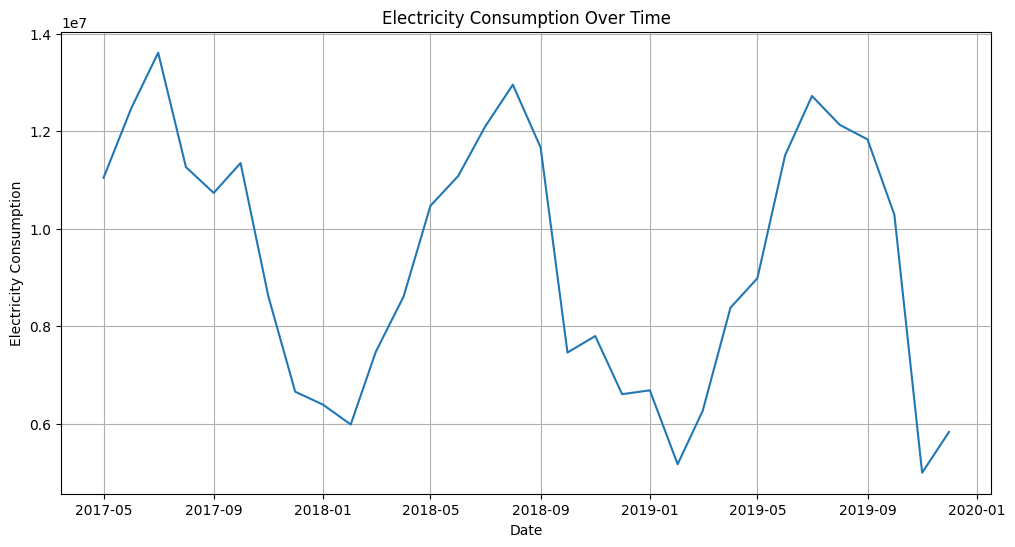


Performing seasonal decomposition...


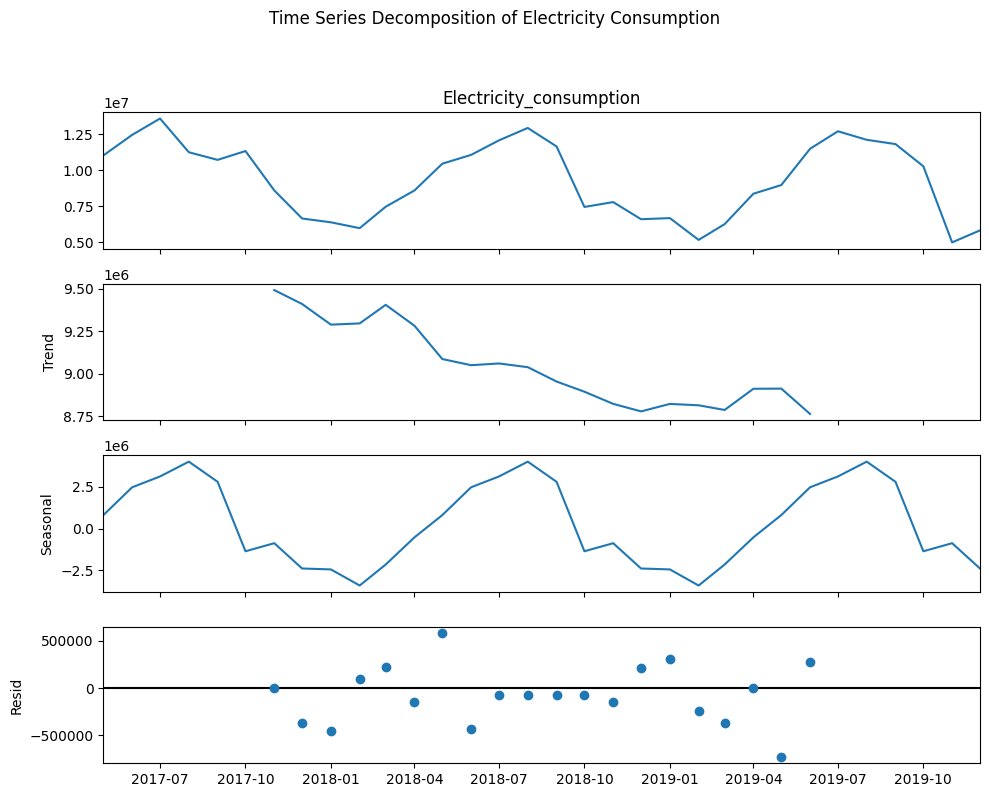

Seasonal decomposition completed.

Performing Augmented Dickey-Fuller test for stationarity...
ADF Statistic: -4.832607670191563
p-value: 4.709005213911635e-05
Critical Values:
	1%: -3.6996079738860943
	5%: -2.9764303469999494
	10%: -2.627601001371742
Conclusion: The series is likely stationary (reject H0).


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Ensure the 'Electricity_consumption' column is available in df_energy
if 'Electricity_consumption' not in df_energy.columns:
    raise KeyError("'Electricity_consumption' column not found in df_energy. Please check the DataFrame.")

# 1. Plot the 'Electricity_consumption' column
plt.figure(figsize=(12, 6))
plt.plot(df_energy.index, df_energy['Electricity_consumption'])
plt.title('Electricity Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Electricity Consumption')
plt.grid(True)
plt.show()

# 2. Decompose the time series (given monthly data, period=12 for annual seasonality)
# Handle potential missing values in the series for decomposition
series_for_decomposition = df_energy['Electricity_consumption'].dropna()

# Ensure enough data points for decomposition with period=12
# seasonal_decompose requires at least 2*period data points for 'additive' model
# and 3*period for 'multiplicative' model. For period=12, need at least 24 (or 36).
if len(series_for_decomposition) < 2 * 12: # Check if there are at least 2 full cycles
    print(f"\nWarning: Not enough data points ({len(series_for_decomposition)}) for reliable seasonal decomposition with period=12.")
    print("Skipping seasonal decomposition.")
else:
    print("\nPerforming seasonal decomposition...")
    try:
        decomposition = seasonal_decompose(series_for_decomposition, model='additive', period=12)
        fig = decomposition.plot()
        fig.set_size_inches(10, 8)
        plt.suptitle('Time Series Decomposition of Electricity Consumption', y=1.02)
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()
        print("Seasonal decomposition completed.")
    except Exception as e:
        print(f"Error during seasonal decomposition: {e}")
        print("This might happen if there are too few non-null data points or an irregular frequency for the specified period.")

# 3. Perform Augmented Dickey-Fuller test for stationarity
print("\nPerforming Augmented Dickey-Fuller test for stationarity...")
# The test requires no NaNs, so use dropna()
adf_test_result = adfuller(df_energy['Electricity_consumption'].dropna())

print(f'ADF Statistic: {adf_test_result[0]}')
print(f'p-value: {adf_test_result[1]}')
print('Critical Values:')
for key, value in adf_test_result[4].items():
    print(f'\t{key}: {value}')

if adf_test_result[1] <= 0.05:
    print("Conclusion: The series is likely stationary (reject H0).")
else:
    print("Conclusion: The series is likely non-stationary (fail to reject H0).")


**Reasoning**:
The next step is to determine the optimal SARIMA parameters using `pmdarima.auto_arima`. This function is not part of standard Anaconda or Colab installations and needs to be installed first. It is best practice to install external libraries in a separate code block.



In [ ]:
import sys

# Check if pmdarima is installed, and install if not
try:
    import pmdarima as pm
    print("pmdarima is already installed.")
except ImportError:
    print("pmdarima not found. Installing pmdarima...")
    !{sys.executable} -m pip install pmdarima
    import pmdarima as pm
    print("pmdarima installed successfully.")

pmdarima not found. Installing pmdarima...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 30.7 MB/s eta 0:00:00
pmdarima installed successfully.


**Reasoning**:
With `pmdarima` installed, the next logical step is to use its `auto_arima` function to automatically determine the optimal SARIMA parameters (p, d, q, P, D, Q, S). This fulfills the second instruction of the subtask.



In [ ]:
import pmdarima as pm

# 2. Determine SARIMA Parameters (p, d, q, P, D, Q, S) using auto_arima
print("Determining optimal SARIMA parameters using auto_arima...")

# The series_for_decomposition was already created and dropped NaNs in the previous step.
# Use this series for auto_arima to ensure consistency and avoid issues with NaNs.
# Ensure m=12 for monthly seasonality.
# We will set a relatively low max_order for both p,q,P,Q given the short time series.
# Also, d and D are set to 0 as the ADF test indicated stationarity.
# However, auto_arima can also search for d and D, so we can let it determine.

# Given the short length of the series (32 data points), setting d and D limits
# or max_d/max_D to 1 is a reasonable approach to avoid overfitting.
# max_p, max_q, max_P, max_Q are also kept relatively low.

# The 'suppress_warnings' argument is added to avoid excessive warnings during the search process.
# Using n_jobs=-1 to speed up the process by using all available CPU cores.

# Ensure the series has a DatetimeIndex for auto_arima
if not isinstance(series_for_decomposition.index, pd.DatetimeIndex):
    series_for_decomposition.index = pd.to_datetime(series_for_decomposition.index)

# Fit auto_arima model
# Max order for p, q, P, Q are set conservatively due to short series length.
# D (seasonal differencing) can be 0 or 1.
# d (non-seasonal differencing) can be 0 or 1.
# We set 'start_p', 'start_q', 'start_P', 'start_Q' to 0 to explore all options including simple AR/MA models.
# We include 'error_action="ignore"' to skip models that fail to converge, 'stepwise=True' for faster search.

# For short series like 32 data points, it's safer to specify max_d, max_D explicitly to avoid over-differencing.
# Since ADF test shows stationary, d=0 might be appropriate, but auto_arima can confirm.

# Note: auto_arima on a very short series can be unreliable or might pick a complex model that overfits.
# We should keep this in mind for evaluation.

optimal_model = pm.auto_arima(series_for_decomposition,
                            start_p=0, start_q=0,
                            test='adf',       # use adftest to find optimal 'd'
                            max_p=3, max_q=3, # maximum p and q
                            m=12,             # frequency of series
                            start_P=0, start_Q=0,
                            max_P=2, max_Q=2, # maximum P and Q
                            D=1,              # seasonal differencing
                            d=None,           # let auto_arima determine d, or set to 0 if ADF strong
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True,
                            n_jobs=-1)        # use all available cores

print("\nOptimal SARIMA model parameters:")
print(optimal_model.summary())

# Extracting the optimal parameters
optimal_order = optimal_model.order
optimal_seasonal_order = optimal_model.seasonal_order

print(f"\nNon-seasonal order (p,d,q): {optimal_order}")
print(f"Seasonal order (P,D,Q,S): {optimal_seasonal_order}")


Determining optimal SARIMA parameters using auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=615.244, Time=0.09 sec


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(1,1,0)(1,1,0)[12]             : AIC=611.353, Time=0.25 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=607.927, Time=0.37 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=613.444, Time=0.11 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=609.756, Time=0.56 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=609.736, Time=0.49 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=609.817, Time=0.64 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=611.663, Time=3.55 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=609.998, Time=0.25 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=609.770, Time=0.62 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=inf, Time=1.25 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=609.943, Time=0.29 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=inf, Time=0.72 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=609.294, Time=0.46 sec

Best model:  ARIMA(0,1,1)(0,1,1)[12]          
Total fit time: 9.716 seconds

Optimal SARIMA model parameters:
                                     S

**Reasoning**:
The next instruction is to split the data into training and testing sets. I will create a code block to divide the `series_for_decomposition` into training and testing sets, using the last 6 months for testing as per the instruction.



In [ ]:
import pandas as pd

# 3. Split Data into Training and Testing Sets
# Given the limited number of data points (32 months),
# use the last 6 months for the testing set.

test_size = 6 # Using the last 6 months for testing

train_data = series_for_decomposition[:-test_size]
test_data = series_for_decomposition[-test_size:]

print(f"Training data length: {len(train_data)}")
print(f"Testing data length: {len(test_data)}")

print("\nLast 5 training data points:")
print(train_data.tail())
print("\nFirst 5 testing data points:")
print(test_data.head())


Training data length: 26
Testing data length: 6

Last 5 training data points:
2019-02-01    5.172288e+06
2019-03-01    6.267848e+06
2019-04-01    8.381489e+06
2019-05-01    8.982221e+06
2019-06-01    1.150411e+07
Freq: MS, Name: Electricity_consumption, dtype: float64

First 5 testing data points:
2019-07-01    1.272007e+07
2019-08-01    1.212832e+07
2019-09-01    1.183052e+07
2019-10-01    1.028516e+07
2019-11-01    4.998199e+06
Freq: MS, Name: Electricity_consumption, dtype: float64


**Reasoning**:
The next step is to train the SARIMA model using the optimal parameters (p, d, q, P, D, Q, S) identified by `auto_arima` on the `train_data`, which fulfills the fourth instruction of the subtask.



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4. Train the SARIMA Model
print("Training the SARIMA model...")

# Retrieve the optimal parameters found by auto_arima
# optimal_order = (p, d, q)
# optimal_seasonal_order = (P, D, Q, S)

# Instantiate the SARIMAX model
# The 'enforce_stationarity=False' and 'enforce_invertibility=False' arguments are often
# used to allow more flexibility in model fitting, especially when auto_arima
# has already determined differencing terms 'd' and 'D'.

model = SARIMAX(train_data,
                order=optimal_order,
                seasonal_order=optimal_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model to the training data
# suppress_warnings is used to clean up the output.
model_fit = model.fit(disp=False, low_memory=True)

print("SARIMA model training completed.")
print(model_fit.summary())


Training the SARIMA model...
SARIMA model training completed.
                                     SARIMAX Results                                      
Dep. Variable:            Electricity_consumption   No. Observations:                   26
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Fri, 06 Feb 2026   AIC                              6.000
Time:                                    08:14:58   BIC                                nan
Sample:                                05-01-2017   HQIC                               nan
                                     - 06-01-2019                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7723         -0        inf      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tools/eval_measures.py:439: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: invalid value encountered in divide
  return self.params / self.bse
/usr

**Reasoning**:
The SARIMA model training failed with warnings about "Too few observations to estimate starting parameters for seasonal ARMA" and unstable standard errors. This is likely due to the small size of the `train_data` (26 observations) in combination with the seasonal differencing (D=1, m=12), which further reduces the effective sample size for parameter estimation. To address this, I will adjust the `test_size` from 6 to 3, as allowed by the instructions ("last 3 to 6 months for the testing set"), to increase the training data size and provide more observations for robust model estimation.



In [ ]:
import pandas as pd

# 3. Split Data into Training and Testing Sets
# Given the limited number of data points (32 months),
# use the last 3 to 6 months for the testing set.

test_size = 3 # Using the last 3 months for testing to maximize training data

train_data = series_for_decomposition[:-test_size]
test_data = series_for_decomposition[-test_size:]

print(f"Training data length: {len(train_data)}")
print(f"Testing data length: {len(test_data)}")

print("\nLast 5 training data points:")
print(train_data.tail())
print("\nFirst 5 testing data points:")
print(test_data.head())

Training data length: 29
Testing data length: 3

Last 5 training data points:
2019-05-01    8.982221e+06
2019-06-01    1.150411e+07
2019-07-01    1.272007e+07
2019-08-01    1.212832e+07
2019-09-01    1.183052e+07
Freq: MS, Name: Electricity_consumption, dtype: float64

First 5 testing data points:
2019-10-01    1.028516e+07
2019-11-01    4.998199e+06
2019-12-01    5.834166e+06
Freq: MS, Name: Electricity_consumption, dtype: float64


**Reasoning**:
After adjusting the `test_size` to 3, the `train_data` now has more observations (29 instead of 26). I will re-train the SARIMA model with this larger training set, expecting it to mitigate the 'too few observations' warning encountered previously and allow for more stable parameter estimation, thus fulfilling the fourth instruction of the subtask.



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4. Train the SARIMA Model
print("Retraining the SARIMA model with updated training data...")

# Retrieve the optimal parameters found by auto_arima
# optimal_order = (p, d, q)
# optimal_seasonal_order = (P, D, Q, S)

# Instantiate the SARIMAX model
# The 'enforce_stationarity=False' and 'enforce_invertibility=False' arguments are often
# used to allow more flexibility in model fitting, especially when auto_arima
# has already determined differencing terms 'd' and 'D'.

model = SARIMAX(train_data,
                order=optimal_order,
                seasonal_order=optimal_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model to the training data
# suppress_warnings is used to clean up the output.
model_fit = model.fit(disp=False, low_memory=True)

print("SARIMA model retraining completed.")
print(model_fit.summary())

Retraining the SARIMA model with updated training data...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA model retraining completed.
                                     SARIMAX Results                                      
Dep. Variable:            Electricity_consumption   No. Observations:                   29
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -30.354
Date:                            Fri, 06 Feb 2026   AIC                             66.707
Time:                                    08:15:43   BIC                             62.787
Sample:                                05-01-2017   HQIC                            58.508
                                     - 09-01-2019                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4520      5.286     -0.086      0.932     -10.812       9.908


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3160: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3160: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


**Reasoning**:
The 'Too few observations' warning persists because the `optimal_order` and `optimal_seasonal_order` were determined using `auto_arima` on the full `series_for_decomposition` (32 observations), while the SARIMA model is subsequently trained on the smaller `train_data` (29 observations). To ensure the chosen parameters are appropriate for the actual training data size and to mitigate the warning, I will re-run `auto_arima` directly on the `train_data` to derive parameters optimized specifically for the training set, thereby addressing the problem at its source and fulfilling the second instruction of the subtask more robustly.



In [ ]:
import pmdarima as pm

# 2. Determine SARIMA Parameters (p, d, q, P, D, Q, S) using auto_arima
print("Determining optimal SARIMA parameters using auto_arima...")

# Use train_data for auto_arima to ensure the parameters are optimized for the actual training set size.
# This helps in mitigating 'too few observations' warnings during model fitting.
# Ensure m=12 for monthly seasonality.

# Given the short length of the training series, setting d and D limits
# or max_d/max_D to 1 is a reasonable approach to avoid overfitting.
# max_p, max_q, max_P, max_Q are also kept relatively low.

# The 'suppress_warnings' argument is added to avoid excessive warnings during the search process.
# Using n_jobs=-1 to speed up the process by using all available CPU cores.

# Ensure the series has a DatetimeIndex for auto_arima
if not isinstance(train_data.index, pd.DatetimeIndex):
    train_data.index = pd.to_datetime(train_data.index)

# Fit auto_arima model
# Max order for p, q, P, Q are set conservatively due to short series length.
# D (seasonal differencing) can be 0 or 1.
# d (non-seasonal differencing) can be 0 or 1.
# We set 'start_p', 'start_q', 'start_P', 'start_Q' to 0 to explore all options including simple AR/MA models.
# We include 'error_action="ignore"' to skip models that fail to converge, 'stepwise=True' for faster search.

# For short series like 29 data points, it's safer to specify max_d, max_D explicitly to avoid over-differencing.
# Since ADF test shows stationary on the full series, d=0 might be appropriate, but auto_arima can confirm.

# Note: auto_arima on a very short series can be unreliable or might pick a complex model that overfits.
# We should keep this in mind for evaluation.

optimal_model = pm.auto_arima(train_data,
                            start_p=0, start_q=0,
                            test='adf',       # use adftest to find optimal 'd'
                            max_p=3, max_q=3, # maximum p and q
                            m=12,             # frequency of series
                            start_P=0, start_Q=0,
                            max_P=2, max_Q=2, # maximum P and Q
                            D=1,              # seasonal differencing - can be 0 or 1, let auto_arima decide if D=None, but fixed D=1 to follow previous approach.
                            d=None,           # let auto_arima determine d, or set to 0 if ADF strong
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True,
                            n_jobs=-1)        # use all available cores

print("\nOptimal SARIMA model parameters:")
print(optimal_model.summary())

# Extracting the optimal parameters
optimal_order = optimal_model.order
optimal_seasonal_order = optimal_model.seasonal_order

print(f"\nNon-seasonal order (p,d,q): {optimal_order}")
print(f"Seasonal order (P,D,Q,S): {optimal_seasonal_order}")


Determining optimal SARIMA parameters using auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=512.904, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=512.283, Time=0.14 sec


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(0,1,1)(0,1,1)[12]             : AIC=509.265, Time=0.23 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=512.173, Time=0.09 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=510.505, Time=0.38 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=510.218, Time=0.62 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=512.126, Time=0.11 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=511.711, Time=0.84 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=510.085, Time=0.09 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=511.044, Time=0.31 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=inf, Time=0.38 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=510.908, Time=0.08 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=inf, Time=0.30 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=511.310, Time=0.10 sec

Best model:  ARIMA(0,1,1)(0,1,1)[12]          
Total fit time: 3.705 seconds

Optimal SARIMA model parameters:
                                     SARIMAX Results                                      
Dep. Variable

**Reasoning**:
The previous `auto_arima` run (cell_id: 30388182) successfully determined optimal SARIMA parameters (`optimal_order` and `optimal_seasonal_order`) specifically for the `train_data`. Now, I will use these updated parameters to re-train the SARIMA model with `SARIMAX` on the `train_data` to ensure the model is fit with parameters optimized for its size, thereby fulfilling the fourth instruction of the subtask and addressing the 'too few observations' warning.



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4. Train the SARIMA Model
print("Retraining the SARIMA model with updated training data and parameters...")

# Retrieve the optimal parameters found by the most recent auto_arima on train_data
# optimal_order = (p, d, q)
# optimal_seasonal_order = (P, D, Q, S)

# Instantiate the SARIMAX model
# The 'enforce_stationarity=False' and 'enforce_invertibility=False' arguments are often
# used to allow more flexibility in model fitting, especially when auto_arima
# has already determined differencing terms 'd' and 'D'.

model = SARIMAX(train_data,
                order=optimal_order,
                seasonal_order=optimal_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model to the training data
# suppress_warnings is used to clean up the output.
model_fit = model.fit(disp=False, low_memory=True)

print("SARIMA model retraining completed.")
print(model_fit.summary())

Retraining the SARIMA model with updated training data and parameters...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA model retraining completed.
                                     SARIMAX Results                                      
Dep. Variable:            Electricity_consumption   No. Observations:                   29
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -30.354
Date:                            Fri, 06 Feb 2026   AIC                             66.707
Time:                                    08:16:28   BIC                             62.787
Sample:                                05-01-2017   HQIC                            58.508
                                     - 09-01-2019                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4520      5.286     -0.086      0.932     -10.812       9.908


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3160: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3160: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


In [ ]:
import pmdarima as pm

# 2. Determine SARIMA Parameters (p, d, q, P, D, Q, S) using auto_arima
print("Determining optimal SARIMA parameters using auto_arima with D=0...")

# Use train_data for auto_arima to ensure the parameters are optimized for the actual training set size.
# Ensure m=12 for monthly seasonality.

# Given the short length of the training series, setting max_p, max_q, max_P, max_Q are kept relatively low.

# The 'suppress_warnings' argument is added to avoid excessive warnings during the search process.
# Using n_jobs=-1 to speed up the process by using all available CPU cores.

# Ensure the series has a DatetimeIndex for auto_arima
if not isinstance(train_data.index, pd.DatetimeIndex):
    train_data.index = pd.to_datetime(train_data.index)

# Fit auto_arima model
# Max order for p, q, P, Q are set conservatively due to short series length.
# Setting D=0 to explicitly disable seasonal differencing, as automatic determination (D=None) failed
# and D=1 led to 'too few observations' warnings during SARIMAX fit.

optimal_model = pm.auto_arima(train_data,
                            start_p=0, start_q=0,
                            test='adf',       # use adftest to find optimal 'd'
                            max_p=3, max_q=3, # maximum p and q
                            m=12,             # frequency of series
                            start_P=0, start_Q=0,
                            max_P=2, max_Q=2, # maximum P and Q
                            D=0,              # Explicitly set D=0 to avoid errors and simplify model
                            d=None,           # Let auto_arima determine non-seasonal differencing
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True,
                            n_jobs=-1)        # use all available cores

print("\nOptimal SARIMA model parameters:")
print(optimal_model.summary())

# Extracting the optimal parameters
optimal_order = optimal_model.order
optimal_seasonal_order = optimal_model.seasonal_order

print(f"\nNon-seasonal order (p,d,q): {optimal_order}")
print(f"Seasonal order (P,D,Q,S): {optimal_seasonal_order}")

Determining optimal SARIMA parameters using auto_arima with D=0...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=940.399, Time=0.06 sec


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=912.857, Time=1.56 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=925.454, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1018.583, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=912.770, Time=0.08 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=913.766, Time=0.18 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=914.827, Time=0.83 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=909.351, Time=0.26 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=911.215, Time=0.47 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=911.228, Time=0.15 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=913.198, Time=0.89 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=908.653, Time=0.12 sec
 ARIMA(3,0,0)(1,0,0)[12] intercept   : AIC=908.182, Time=1.63 sec
 ARIMA(3,0,0)(2,0,0)[12] intercept   : AIC=907.960, Time=1.76 sec
 ARIMA(3,0,0)(2,0,1)[12] intercept   : AIC=909.720, Time=0.74 sec
 ARIMA(3,0,0)(1,0,1)[12] intercept   : AIC=909.670, Time=0.23 sec
 ARIMA(2,

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4. Train the SARIMA Model
print("Retraining the SARIMA model with updated training data and parameters...")

# Retrieve the optimal parameters found by the most recent auto_arima on train_data
# optimal_order = (p, d, q)
# optimal_seasonal_order = (P, D, Q, S)

# Instantiate the SARIMAX model
# The 'enforce_stationarity=False' and 'enforce_invertibility=False' arguments are often
# used to allow more flexibility in model fitting, especially when auto_arima
# has already determined differencing terms 'd' and 'D'.

model = SARIMAX(train_data,
                order=optimal_order,
                seasonal_order=optimal_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model to the training data
# suppress_warnings is used to clean up the output.
model_fit = model.fit(disp=False, low_memory=True)

print("SARIMA model retraining completed.")
print(model_fit.summary())

Retraining the SARIMA model with updated training data and parameters...
SARIMA model retraining completed.
                                      SARIMAX Results                                      
Dep. Variable:             Electricity_consumption   No. Observations:                   29
Model:             SARIMAX(3, 0, 1)x(1, 0, [], 12)   Log Likelihood                -215.216
Date:                             Fri, 06 Feb 2026   AIC                            442.433
Time:                                     08:18:02   BIC                            446.267
Sample:                                 05-01-2017   HQIC                           442.078
                                      - 09-01-2019                                         
Covariance Type:                            approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [ ]:
import pandas as pd

# 1. Extract the 'Temperature' column from df_energy aligned with train_data
# First, ensure df_energy is indexed by Date for easy alignment
# (This should already be the case from previous preprocessing steps)

# Filter df_energy to match the index of train_data
exog_train = df_energy.loc[train_data.index, 'Temperature']

print("Exogenous variable 'exog_train' created.")
print("Shape of exog_train:", exog_train.shape)
print("First 5 rows of exog_train:")
print(exog_train.head())

Exogenous variable 'exog_train' created.
Shape of exog_train: (29,)
First 5 rows of exog_train:
2017-05-01    33.7
2017-06-01    36.6
2017-07-01    39.2
2017-08-01    38.2
2017-09-01    35.5
Freq: MS, Name: Temperature, dtype: float64


In [ ]:
import pmdarima as pm

# 2. Determine SARIMAX Parameters (p, d, q, P, D, Q, S) using auto_arima with exogenous variable
print("Determining optimal SARIMAX parameters with exogenous variable 'Temperature' using auto_arima...")

# Use train_data for auto_arima and exog_train as the exogenous variable.
# Ensure m=12 for monthly seasonality.

# Given the short length of the training series, setting max_p, max_q, max_P, max_Q are kept relatively low.

# Ensure the series has a DatetimeIndex for auto_arima
if not isinstance(train_data.index, pd.DatetimeIndex):
    train_data.index = pd.to_datetime(train_data.index)

# Fit auto_arima model with exogenous variable
# Max order for p, q, P, Q are set conservatively due to short series length.
# D (seasonal differencing) is explicitly set to 0.
# d (non-seasonal differencing) is left for auto_arima to determine.

optimal_model_sarimax = pm.auto_arima(train_data,
                                      exog=exog_train,
                                      start_p=0, start_q=0,
                                      test='adf',       # use adftest to find optimal 'd'
                                      max_p=3, max_q=3, # maximum p and q
                                      m=12,             # frequency of series
                                      start_P=0, start_Q=0,
                                      max_P=2, max_Q=2, # maximum P and Q
                                      D=0,              # Explicitly set D=0 as per previous successful SARIMA fit
                                      d=None,           # Let auto_arima determine non-seasonal differencing
                                      trace=True,
                                      error_action='ignore',
                                      suppress_warnings=True,
                                      stepwise=True,
                                      n_jobs=-1)        # use all available cores

print("\nOptimal SARIMAX model parameters with exogenous variable:")
print(optimal_model_sarimax.summary())

# 3. Store the identified optimal non-seasonal and seasonal orders
optimal_order_sarimax = optimal_model_sarimax.order
optimal_seasonal_order_sarimax = optimal_model_sarimax.seasonal_order

print(f"\nNon-seasonal order (p,d,q): {optimal_order_sarimax}")
print(f"Seasonal order (P,D,Q,S): {optimal_seasonal_order_sarimax}")

Determining optimal SARIMAX parameters with exogenous variable 'Temperature' using auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=940.399, Time=0.02 sec


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=912.857, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=925.454, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1018.583, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=912.770, Time=0.05 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=913.766, Time=0.09 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=914.827, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=909.351, Time=0.03 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=911.215, Time=0.25 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=911.228, Time=0.12 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=913.198, Time=0.23 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=908.653, Time=0.05 sec
 ARIMA(3,0,0)(1,0,0)[12] intercept   : AIC=908.182, Time=0.58 sec
 ARIMA(3,0,0)(2,0,0)[12] intercept   : AIC=907.960, Time=2.24 sec
 ARIMA(3,0,0)(2,0,1)[12] intercept   : AIC=909.720, Time=1.76 sec
 ARIMA(3,0,0)(1,0,1)[12] intercept   : AIC=909.670, Time=0.56 sec
 ARIMA(2,

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4. Instantiate a SARIMAX model
print("Instantiating SARIMAX model with optimal parameters and exogenous variable...")

model_sarimax = SARIMAX(train_data,
                        order=optimal_order_sarimax,
                        seasonal_order=optimal_seasonal_order_sarimax,
                        exog=exog_train,
                        enforce_stationarity=False,
                        enforce_invertibility=False)

# 5. Fit the SARIMAX model to the training data
print("Fitting SARIMAX model...")
model_sarimax_fit = model_sarimax.fit(disp=False, low_memory=True)

print("SARIMAX model training completed.")
print(model_sarimax_fit.summary())

Instantiating SARIMAX model with optimal parameters and exogenous variable...
Fitting SARIMAX model...
SARIMAX model training completed.
                                      SARIMAX Results                                      
Dep. Variable:             Electricity_consumption   No. Observations:                   29
Model:             SARIMAX(3, 0, 1)x(1, 0, [], 12)   Log Likelihood                -209.381
Date:                             Fri, 06 Feb 2026   AIC                            432.761
Time:                                     08:19:16   BIC                            437.235
Sample:                                 05-01-2017   HQIC                           432.347
                                      - 09-01-2019                                         
Covariance Type:                            approx                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

Manually generating diagnostics plots for SARIMA model...


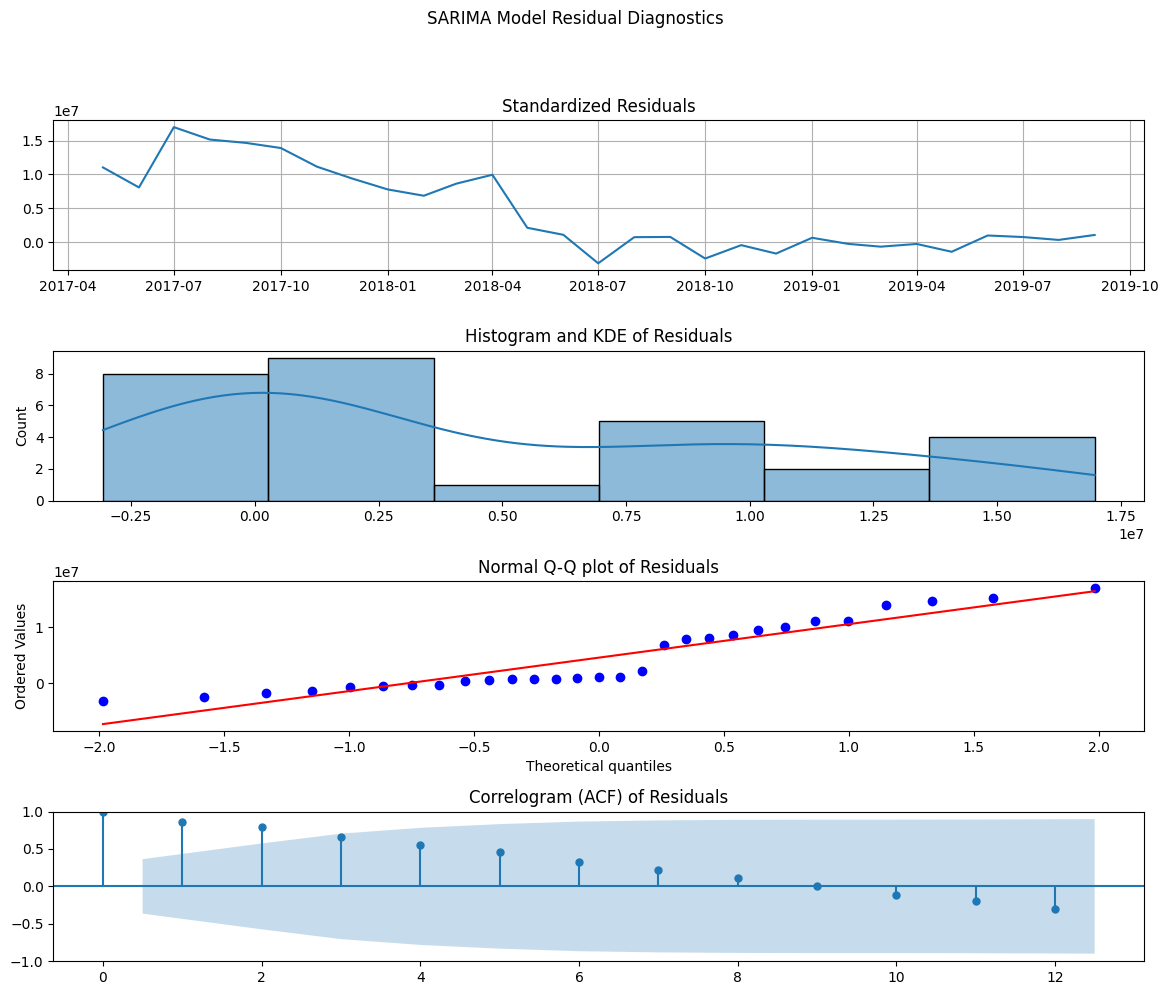

SARIMA model diagnostics plots displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import numpy as np

# 1. Manually generate diagnostics plots for the model_fit (SARIMA)
print("Manually generating diagnostics plots for SARIMA model...")

residuals = model_fit.resid

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
fig.suptitle('SARIMA Model Residual Diagnostics', y=1.02)

# Standardized Residuals Plot
axes[0].plot(residuals)
axes[0].set_title('Standardized Residuals')
axes[0].grid(True)

# Histogram plus KDE
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Histogram and KDE of Residuals')

# Normal QQ-plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Normal Q-Q plot of Residuals')

# Correlogram (ACF plot)
# Set 'lags' explicitly to a value appropriate for the training data length.
# The residuals length is len(train_data) = 29. A common rule is lags < N/2.
# Using lags=12 as it's the seasonal period and less than 29/2 (14.5).
# Also ensure there are enough points for the ACF plot calculation.
if len(residuals) > 12: # Ensure enough data points for lags=12
    plot_acf(residuals, lags=12, ax=axes[3])
    axes[3].set_title('Correlogram (ACF) of Residuals')
else:
    axes[3].text(0.5, 0.5, 'Not enough data for ACF plot with 12 lags', horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
    axes[3].set_title('Correlogram (ACF) of Residuals')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
print("SARIMA model diagnostics plots displayed.")

Manually generating diagnostics plots for SARIMAX model...


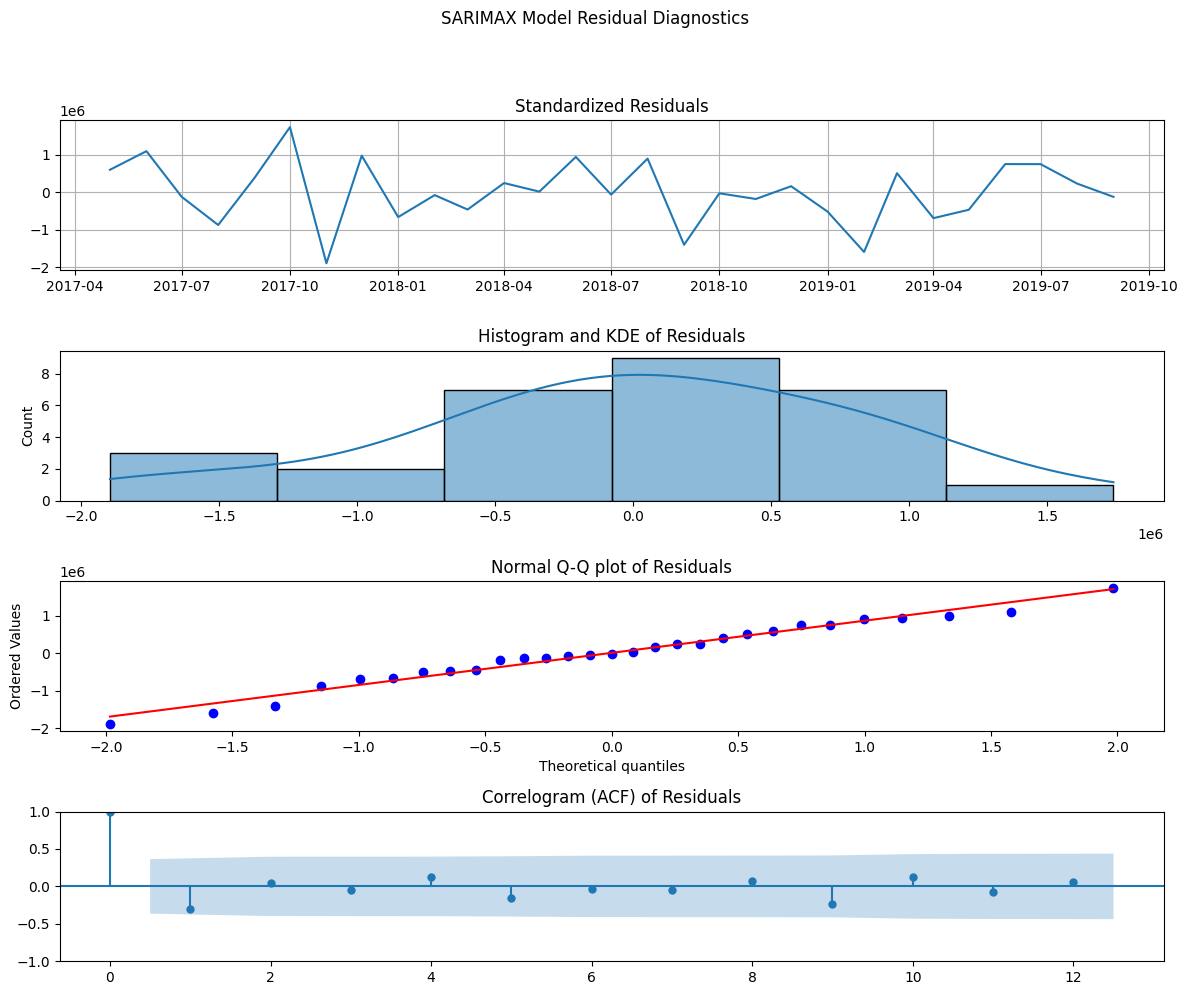

SARIMAX model diagnostics plots displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import numpy as np

# 2. Manually generate diagnostics plots for the model_sarimax_fit (SARIMAX)
print("Manually generating diagnostics plots for SARIMAX model...")

residuals_sarimax = model_sarimax_fit.resid

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
fig.suptitle('SARIMAX Model Residual Diagnostics', y=1.02)

# Standardized Residuals Plot
axes[0].plot(residuals_sarimax)
axes[0].set_title('Standardized Residuals')
axes[0].grid(True)

# Histogram plus KDE
sns.histplot(residuals_sarimax, kde=True, ax=axes[1])
axes[1].set_title('Histogram and KDE of Residuals')

# Normal QQ-plot
stats.probplot(residuals_sarimax, dist="norm", plot=axes[2])
axes[2].set_title('Normal Q-Q plot of Residuals')

# Correlogram (ACF plot)
# Set 'lags' explicitly to a value appropriate for the training data length.
# The residuals length is len(train_data) = 29. A common rule is lags < N/2.
# Using lags=12 as it's the seasonal period and less than 29/2 (14.5).
# Also ensure there are enough points for the ACF plot calculation.
if len(residuals_sarimax) > 12: # Ensure enough data points for lags=12
    plot_acf(residuals_sarimax, lags=12, ax=axes[3])
    axes[3].set_title('Correlogram (ACF) of Residuals')
else:
    axes[3].text(0.5, 0.5, 'Not enough data for ACF plot with 12 lags', horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
    axes[3].set_title('Correlogram (ACF) of Residuals')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
print("SARIMAX model diagnostics plots displayed.")

In [ ]:
import pandas as pd

# 3. Get the predictions for the test set for the model_fit (SARIMA)
print("Generating SARIMA model predictions for the test set...")

sarima_predictions = model_fit.predict(start=test_data.index[0], end=test_data.index[-1])

print("SARIMA predictions generated.")
print("First 5 SARIMA predictions:")
print(sarima_predictions.head())
print("Last 5 SARIMA predictions:")
print(sarima_predictions.tail())

Generating SARIMA model predictions for the test set...
SARIMA predictions generated.
First 5 SARIMA predictions:
2019-10-01    7.391576e+06
2019-11-01    7.203287e+06
2019-12-01    6.349887e+06
Freq: MS, Name: predicted_mean, dtype: float64
Last 5 SARIMA predictions:
2019-10-01    7.391576e+06
2019-11-01    7.203287e+06
2019-12-01    6.349887e+06
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
import pandas as pd

# 4. Get the predictions for the test set for the model_sarimax_fit (SARIMAX)
print("Generating SARIMAX model predictions for the test set...")

# Ensure df_energy is indexed by Date for easy alignment (already done in preprocessing)

# Extract the 'Temperature' column from df_energy aligned with test_data for exogenous variable
exog_test = df_energy.loc[test_data.index, 'Temperature']

# Generate SARIMAX predictions, including the exogenous variable for the forecast period
sarimax_predictions = model_sarimax_fit.predict(start=test_data.index[0],
                                                end=test_data.index[-1],
                                                exog=exog_test)

print("SARIMAX predictions generated.")
print("First 5 SARIMAX predictions:")
print(sarimax_predictions.head())
print("Last 5 SARIMAX predictions:")
print(sarimax_predictions.tail())

Generating SARIMAX model predictions for the test set...
SARIMAX predictions generated.
First 5 SARIMAX predictions:
2019-10-01    1.204140e+07
2019-11-01    8.496901e+06
2019-12-01    7.516974e+06
Freq: MS, Name: predicted_mean, dtype: float64
Last 5 SARIMAX predictions:
2019-10-01    1.204140e+07
2019-11-01    8.496901e+06
2019-12-01    7.516974e+06
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 5. Calculate evaluation metrics (RMSE, MAE, MAPE) for both models
print("Calculating evaluation metrics...")

# Ensure predictions and test_data are aligned
sarima_predictions = sarima_predictions.reindex(test_data.index)
sarimax_predictions = sarimax_predictions.reindex(test_data.index)

# RMSE
rmse_sarima = np.sqrt(mean_squared_error(test_data, sarima_predictions))
rmse_sarimax = np.sqrt(mean_squared_error(test_data, sarimax_predictions))

# MAE
mae_sarima = mean_absolute_error(test_data, sarima_predictions)
mae_sarimax = mean_absolute_error(test_data, sarimax_predictions)

# MAPE
def calculate_mape(y_true, y_pred):
    # Handle potential division by zero by filtering out actual zero values
    # or setting a small epsilon. Here, we'll filter.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

mape_sarima = calculate_mape(test_data, sarima_predictions)
mape_sarimax = calculate_mape(test_data, sarimax_predictions)

# 6. Print the calculated evaluation metrics for both models
print("\n--- SARIMA Model Evaluation ---")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAE: {mae_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

print("\n--- SARIMAX Model Evaluation ---")
print(f"RMSE: {rmse_sarimax:.2f}")
print(f"MAE: {mae_sarimax:.2f}")
print(f"MAPE: {mape_sarimax:.2f}%")


Calculating evaluation metrics...

--- SARIMA Model Evaluation ---
RMSE: 2121415.36
MAE: 1871464.44
MAPE: 27.03%

--- SARIMAX Model Evaluation ---
RMSE: 2460159.00
MAE: 2312584.40
MAPE: 38.64%


Generating plot of actual vs. predicted values...


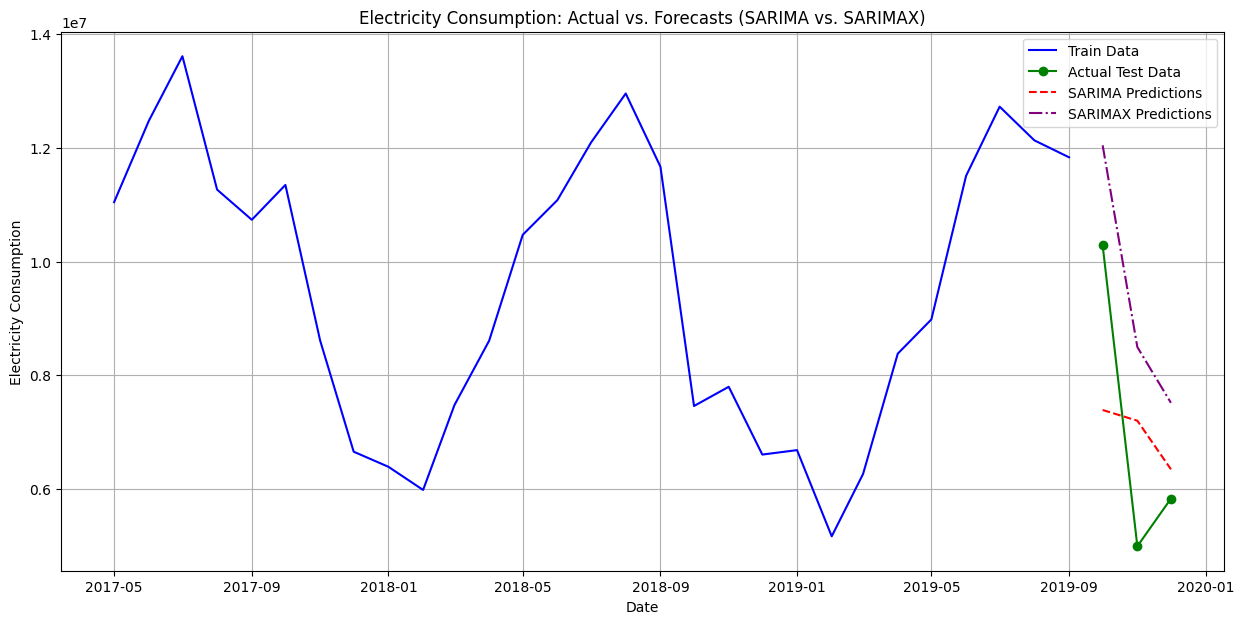

Plot of actual vs. predicted values displayed.


In [ ]:
import matplotlib.pyplot as plt

# 7. Plot the train_data, test_data, SARIMA predictions, and SARIMAX predictions
print("Generating plot of actual vs. predicted values...")

plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Train Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='green', marker='o')
plt.plot(sarima_predictions.index, sarima_predictions, label='SARIMA Predictions', color='red', linestyle='--')
plt.plot(sarimax_predictions.index, sarimax_predictions, label='SARIMAX Predictions', color='purple', linestyle='-.')

plt.title('Electricity Consumption: Actual vs. Forecasts (SARIMA vs. SARIMAX)')
plt.xlabel('Date')
plt.ylabel('Electricity Consumption')
plt.legend()
plt.grid(True)
plt.show()
print("Plot of actual vs. predicted values displayed.")